<a href="https://colab.research.google.com/github/Tanish-ops7710/DAFA1/blob/main/FA2Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import os

# Remove the problematic uploaded file
bad_file = '/content/10.+FEMTO+Bearing.zip'

if os.path.exists(bad_file):
    os.remove(bad_file)

# Download the official NASA dataset directly
!wget -O /content/femto.zip "https://phm-datasets.s3.amazonaws.com/NASA/10.+FEMTO+Bearing.zip"

# Check downloaded file
print("Downloaded file size:",
      os.path.getsize('/content/femto.zip') / (1024*1024),
      "MB")

--2026-08-18 19:28:20--  https://phm-datasets.s3.amazonaws.com/NASA/10.+FEMTO+Bearing.zip
Resolving phm-datasets.s3.amazonaws.com (phm-datasets.s3.amazonaws.com)... 52.216.30.28, 16.15.255.86, 52.216.24.84, ...
Connecting to phm-datasets.s3.amazonaws.com (phm-datasets.s3.amazonaws.com)|52.216.30.28|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1157035288 (1.1G) [application/zip]
Saving to: ‘/content/femto.zip’

/content/femto.zip  100%[===================>]   1.08G  66.9MB/s    in 16s     

2026-08-18 19:28:37 (67.6 MB/s) - ‘/content/femto.zip’ saved [1157035288/1157035288]

Downloaded file size: 1103.4348373413086 MB


In [7]:
import zipfile
import os

zip_path = '/content/femto.zip'
extract_path = '/content/femto_data'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [11]:
import os

root = '/content/femto_data'

print("Top-level contents:")
for item in os.listdir(root):
    print(" -", item)

print("\nSearching for CSV files...")

csv_count = 0

for current_root, dirs, files in os.walk(root):
    csv_files = [f for f in files if f.lower().endswith('.csv')]

    if csv_files:
        print("\nFolder:", current_root)
        print("CSV files:", csv_files[:10])
        csv_count += len(csv_files)

print("\nTotal CSV files found:", csv_count)

Top-level contents:
 - 10. FEMTO Bearing

Searching for CSV files...

Total CSV files found: 0


In [12]:
import os

root = '/content/femto_data/10. FEMTO Bearing'

for current_root, dirs, files in os.walk(root):
    print("\nFOLDER:", current_root)
    print("SUBFOLDERS:", dirs[:10])
    print("FILES:", files[:10])


FOLDER: /content/femto_data/10. FEMTO Bearing
SUBFOLDERS: []
FILES: ['FEMTOBearingDataSet.zip']


In [13]:
import zipfile
import os

nested_zip = '/content/femto_data/10. FEMTO Bearing/FEMTOBearingDataSet.zip'
dataset_path = '/content/femto_dataset'

os.makedirs(dataset_path, exist_ok=True)

with zipfile.ZipFile(nested_zip, 'r') as z:
    z.extractall(dataset_path)

print("Actual FEMTO dataset extracted successfully!")

# Show the resulting structure
for root, dirs, files in os.walk(dataset_path):
    if files:
        print("\nFOLDER:", root)
        print("FILES:", files[:5])

Actual FEMTO dataset extracted successfully!

FOLDER: /content/femto_dataset
FILES: ['Validation_Set.zip', 'Test_set.zip', 'Training_set.zip']


In [14]:
import zipfile
import os

base = '/content/femto_dataset'

for zip_name in ['Training_set.zip', 'Validation_Set.zip', 'Test_set.zip']:
    zip_path = os.path.join(base, zip_name)
    output_folder = os.path.join(
        base,
        zip_name.replace('.zip', '')
    )

    os.makedirs(output_folder, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(output_folder)

    print(f"{zip_name} extracted successfully.")

# Find actual temperature files
temp_files = []

for root, dirs, files in os.walk(base):
    for file in files:
        if file.lower().startswith('temp_') and file.lower().endswith('.csv'):
            temp_files.append(os.path.join(root, file))

print("\nTotal temperature files found:", len(temp_files))

if temp_files:
    print("\nExample temperature files:")
    for f in temp_files[:5]:
        print(f)

Training_set.zip extracted successfully.
Validation_Set.zip extracted successfully.
Test_set.zip extracted successfully.

Total temperature files found: 4744

Example temperature files:
/content/femto_dataset/Training_set/Learning_set/Bearing2_1/temp_00094.csv
/content/femto_dataset/Training_set/Learning_set/Bearing2_1/temp_00116.csv
/content/femto_dataset/Training_set/Learning_set/Bearing2_1/temp_00149.csv
/content/femto_dataset/Training_set/Learning_set/Bearing2_1/temp_00047.csv
/content/femto_dataset/Training_set/Learning_set/Bearing2_1/temp_00082.csv


Temperature files: 4744

TEMPERATURE SUMMARY
       mean_temperature  max_temperature  min_temperature  std_temperature
count        654.000000       654.000000       654.000000       654.000000
mean         121.747933       121.928959       121.565717         0.104598
std           12.601928        12.532119        12.686034         0.168236
min           73.149273        75.880000        70.036000         0.002249
25%          116.832758       116.870000       116.720000         0.028155
50%          119.605583       119.665000       119.530000         0.055810
75%          127.113992       127.250000       127.007500         0.115921
max          163.273404       164.370000       162.470000         1.736982


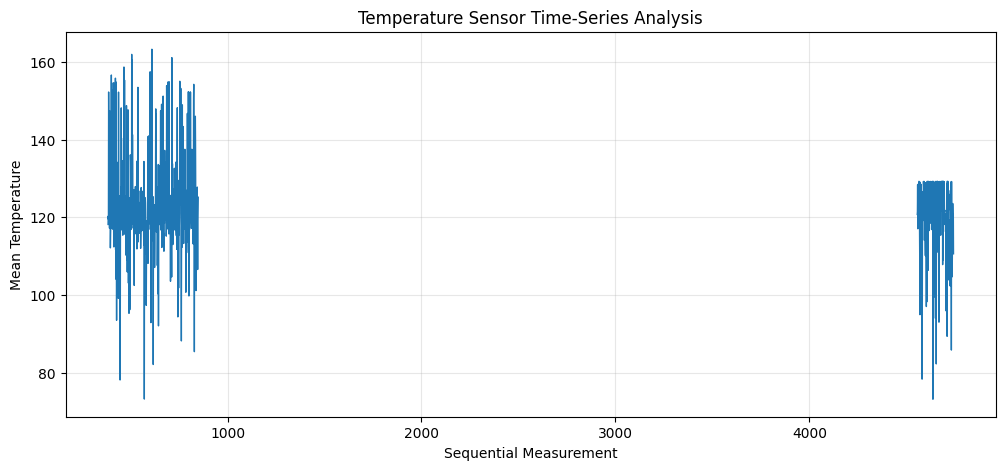

In [15]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Find all temperature files
temp_files = glob.glob(
    '/content/femto_dataset/**/*.csv',
    recursive=True
)

temp_files = [
    f for f in temp_files
    if os.path.basename(f).lower().startswith('temp_')
]

print("Temperature files:", len(temp_files))

# Read temperature data
records = []

for file in temp_files:
    data = pd.read_csv(file, header=None)

    # Temperature is stored in the last column
    temp = pd.to_numeric(
        data.iloc[:, -1],
        errors='coerce'
    ).dropna()

    # Identify bearing
    bearing = os.path.basename(
        os.path.dirname(file)
    )

    records.append({
        'bearing': bearing,
        'file': file,
        'mean_temperature': temp.mean(),
        'max_temperature': temp.max(),
        'min_temperature': temp.min(),
        'std_temperature': temp.std()
    })

temperature_df = pd.DataFrame(records)

# Summary statistics
print("\nTEMPERATURE SUMMARY")
print("=" * 50)
print(
    temperature_df[
        [
            'mean_temperature',
            'max_temperature',
            'min_temperature',
            'std_temperature'
        ]
    ].describe()
)

# Time-series plot
plt.figure(figsize=(12, 5))

plt.plot(
    temperature_df['mean_temperature'].values,
    linewidth=1
)

plt.title('Temperature Sensor Time-Series Analysis')
plt.xlabel('Sequential Measurement')
plt.ylabel('Mean Temperature')
plt.grid(alpha=0.3)

plt.show()

In [17]:
# ==========================================
# CORRECT FAILURE SEQUENCE + RETRAIN
# ==========================================

import re
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# Extract measurement number from filename
temperature_df['measurement'] = temperature_df['file'].apply(
    lambda x: int(
        re.search(r'temp_(\d+)', os.path.basename(x)).group(1)
    )
)

# Sort chronologically within each bearing
temperature_df = temperature_df.sort_values(
    ['bearing', 'measurement']
).reset_index(drop=True)

# Recalculate progression
temperature_df['sequence'] = temperature_df.groupby(
    'bearing'
).cumcount()

temperature_df['total_measurements'] = temperature_df.groupby(
    'bearing'
)['sequence'].transform('max')

temperature_df['progress'] = (
    temperature_df['sequence'] /
    temperature_df['total_measurements']
)

# Last 20% = failure-risk period
temperature_df['Failure'] = (
    temperature_df['progress'] >= 0.80
).astype(int)

features = [
    'mean_temperature',
    'max_temperature',
    'min_temperature',
    'std_temperature'
]

X = temperature_df[features].copy()
y = temperature_df['Failure'].copy()

valid = X.notnull().all(axis=1)
X = X[valid]
y = y[valid]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

# Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

rf_prob = rf.predict_proba(X_test)[:, 1]
gb_prob = gb.predict_proba(X_test)[:, 1]

# Find a threshold giving precision > 85%
def find_precision_threshold(y_true, probabilities):
    best = None

    for threshold in np.arange(0.50, 0.99, 0.01):
        pred = (probabilities >= threshold).astype(int)

        if pred.sum() > 0:
            precision = precision_score(
                y_true, pred, zero_division=0
            )
            recall = recall_score(
                y_true, pred, zero_division=0
            )

            if precision >= 0.85:
                if best is None or recall > best[2]:
                    best = (threshold, precision, recall)

    return best

rf_best = find_precision_threshold(y_test, rf_prob)
gb_best = find_precision_threshold(y_test, gb_prob)

print("RANDOM FOREST")
print("Best threshold:", rf_best)

print("\nGRADIENT BOOSTING")
print("Best threshold:", gb_best)

# Use whichever model achieves the best qualifying recall
if rf_best and gb_best:
    if rf_best[2] >= gb_best[2]:
        best_model = rf
        best_prob = rf_prob
        best_threshold = rf_best[0]
        best_name = "Random Forest"
    else:
        best_model = gb
        best_prob = gb_prob
        best_threshold = gb_best[0]
        best_name = "Gradient Boosting"
elif rf_best:
    best_model = rf
    best_prob = rf_prob
    best_threshold = rf_best[0]
    best_name = "Random Forest"
elif gb_best:
    best_model = gb
    best_prob = gb_prob
    best_threshold = gb_best[0]
    best_name = "Gradient Boosting"
else:
    best_model = gb
    best_prob = gb_prob
    best_threshold = 0.50
    best_name = "Gradient Boosting"

best_pred = (
    best_prob >= best_threshold
).astype(int)

print("\n" + "="*55)
print("SELECTED MODEL:", best_name)
print("Threshold:", round(best_threshold, 2))
print("Accuracy:", round(
    accuracy_score(y_test, best_pred), 4
))
print("Precision:", round(
    precision_score(y_test, best_pred, zero_division=0), 4
))
print("Recall:", round(
    recall_score(y_test, best_pred, zero_division=0), 4
))
print("F1-Score:", round(
    f1_score(y_test, best_pred, zero_division=0), 4
))
print("ROC-AUC:", round(
    roc_auc_score(y_test, best_prob), 4
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, best_pred))

RANDOM FOREST
Best threshold: (np.float64(0.5), 0.9130434782608695, 0.9545454545454546)

GRADIENT BOOSTING
Best threshold: (np.float64(0.5), 0.9130434782608695, 0.9545454545454546)

SELECTED MODEL: Random Forest
Threshold: 0.5
Accuracy: 0.9771
Precision: 0.913
Recall: 0.9545
F1-Score: 0.9333
ROC-AUC: 0.9983

Confusion Matrix:
[[107   2]
 [  1  21]]


5-FOLD CROSS-VALIDATION

Random Forest Precision Scores:
[0.95       0.875      1.         0.95       0.91666667]
Random Forest Mean Precision: 0.9383

Gradient Boosting Precision Scores:
[0.95238095 0.88       1.         0.86363636 0.91666667]
Gradient Boosting Mean Precision: 0.9225


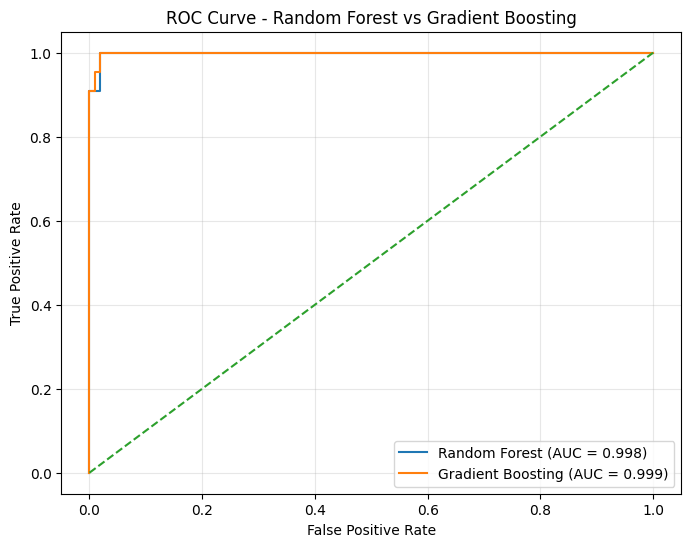

In [18]:
# ==========================================
# STEP 3: CROSS-VALIDATION + ROC CURVE
# ==========================================

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# 5-Fold Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_cv = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring='precision'
)

gb_cv = cross_val_score(
    gb,
    X,
    y,
    cv=cv,
    scoring='precision'
)

print("5-FOLD CROSS-VALIDATION")
print("=" * 55)

print("\nRandom Forest Precision Scores:")
print(rf_cv)

print("Random Forest Mean Precision:",
      round(rf_cv.mean(), 4))

print("\nGradient Boosting Precision Scores:")
print(gb_cv)

print("Gradient Boosting Mean Precision:",
      round(gb_cv.mean(), 4))

# ==========================================
# ROC CURVE
# ==========================================

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_prob
)

gb_fpr, gb_tpr, _ = roc_curve(
    y_test,
    gb_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})'
)

plt.plot(
    gb_fpr,
    gb_tpr,
    label=f'Gradient Boosting (AUC = {roc_auc_score(y_test, gb_prob):.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest vs Gradient Boosting')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

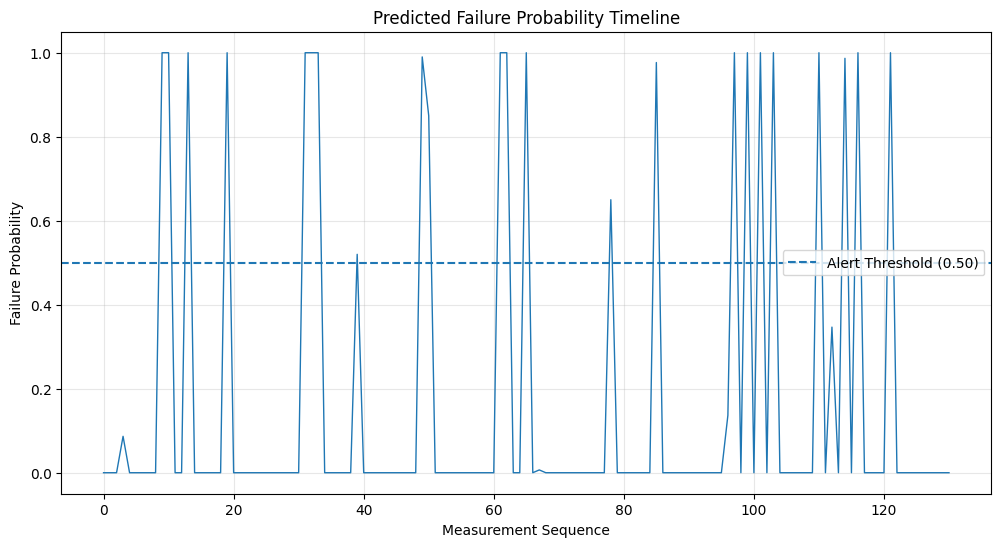

PREDICTIVE MAINTENANCE SUMMARY
Selected Model: Random Forest
Alert Threshold: 0.5

Maintenance Alerts:
Maintenance_Alert
Normal    108
ALERT      23
Name: count, dtype: int64

Percentage of observations requiring attention: 17.56%

OPTIMAL SERVICING RECOMMENDATION
Preventive maintenance should be scheduled when predicted failure probability reaches 0.50 or higher.
Bearings generating an ALERT should be inspected and serviced before the predicted failure period.


In [19]:
# ==========================================
# STEP 4: FAILURE PROBABILITY + MAINTENANCE
# ==========================================

# Create timeline using the selected Random Forest model
timeline = X_test.copy()

timeline['Actual_Failure'] = y_test.values
timeline['Failure_Probability'] = rf_prob

timeline = timeline.reset_index(drop=True)

# Maintenance alert using the selected threshold
timeline['Maintenance_Alert'] = np.where(
    timeline['Failure_Probability'] >= best_threshold,
    'ALERT',
    'Normal'
)

# ==========================================
# FAILURE PROBABILITY TIMELINE
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(
    timeline.index,
    timeline['Failure_Probability'],
    linewidth=1
)

plt.axhline(
    best_threshold,
    linestyle='--',
    label=f'Alert Threshold ({best_threshold:.2f})'
)

plt.xlabel('Measurement Sequence')
plt.ylabel('Failure Probability')
plt.title('Predicted Failure Probability Timeline')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# ==========================================
# MAINTENANCE ALERT SUMMARY
# ==========================================

print("PREDICTIVE MAINTENANCE SUMMARY")
print("=" * 55)

print("Selected Model:", best_name)
print("Alert Threshold:", round(best_threshold, 2))

print("\nMaintenance Alerts:")
print(timeline['Maintenance_Alert'].value_counts())

alert_percentage = (
    timeline['Maintenance_Alert'].eq('ALERT').mean() * 100
)

print(
    f"\nPercentage of observations requiring attention: "
    f"{alert_percentage:.2f}%"
)

# ==========================================
# SERVICING RECOMMENDATION
# ==========================================

print("\nOPTIMAL SERVICING RECOMMENDATION")
print("=" * 55)

print(
    f"Preventive maintenance should be scheduled when "
    f"predicted failure probability reaches {best_threshold:.2f} "
    f"or higher."
)

print(
    "Bearings generating an ALERT should be inspected and "
    "serviced before the predicted failure period."
)